STUDENT SCORE PREDICTOR

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Features
# Columns: Hours Studied, Sleep Hours, Attendance

X = np.array([
    [1, 5, 62],
    [2, 6, 65],
    [3, 5, 68],
    [4, 7, 70],
    [5, 6, 72],
    [6, 7, 75],
    [7, 8, 78],
    [8, 7, 80],
    [9, 8, 82],
    [10, 8, 85]
], dtype=float)

# Target (Exam Score)

y = np.array([
    33,
    42,
    43,
    56,
    58,
    67,
    75,
    79,
    87,
    93
], dtype=float)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst Student:")
print("Features:", X[0])
print("Actual Score:", y[0])

Shape of X: (10, 3)
Shape of y: (10,)

First Student:
Features: [ 1.  5. 62.]
Actual Score: 33.0


In [3]:
print("X:\n")
print(X)

print("\ny:\n")
print(y)
print("\nNumber of students :", X.shape[0])
print("Number of features :", X.shape[1])

X:

[[ 1.  5. 62.]
 [ 2.  6. 65.]
 [ 3.  5. 68.]
 [ 4.  7. 70.]
 [ 5.  6. 72.]
 [ 6.  7. 75.]
 [ 7.  8. 78.]
 [ 8.  7. 80.]
 [ 9.  8. 82.]
 [10.  8. 85.]]

y:

[33. 42. 43. 56. 58. 67. 75. 79. 87. 93.]

Number of students : 10
Number of features : 3


In [4]:
n=X.shape[1]
weights=np.zeros(n)
bias=0
print("weights:",weights)
print("bias:",bias)

weights: [0. 0. 0.]
bias: 0


Prediction Function

y^​=XW+b

In [5]:
def predict(X,weights,bias):
          return np.dot(X,weights) + bias

cost function

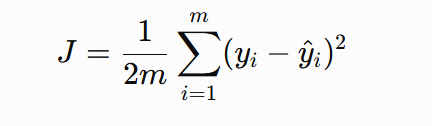

In [6]:
def cost_function(y,predictions):
          m=len(y)
          cost=(1/(2*m))*np.sum((y-predictions)**2)
          return cost

In [7]:
predictions=predict(X,weights,bias)
cost=cost_function(y,predictions)
print(cost)

2188.75


Gradient Descent


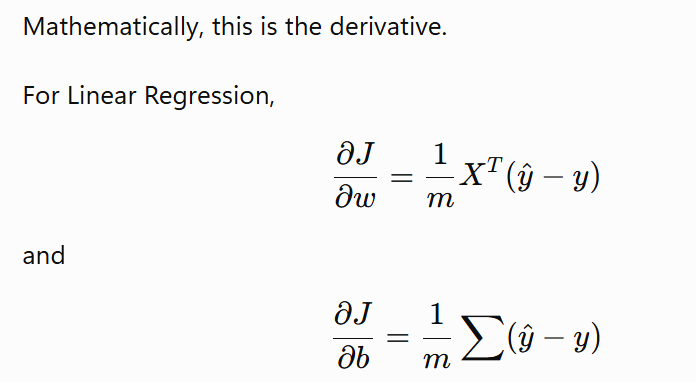

In [8]:
def compute_gradients(X, y, predictions):
    m = len(y)

    dw = (1 / m) * np.dot(X.T, (predictions - y))
    db = (1 / m) * np.sum(predictions - y)

    return dw, db

In [9]:
learning_rate = 0.0001
epochs = 1000

cost_history = []

for epoch in range(epochs):
    # Step 1: Predict
    predictions = predict(X, weights, bias)

    # Step 2: Calculate Cost
    cost = cost_function(y, predictions)

    # Step 3: Compute Gradients
    dw, db = compute_gradients(X, y, predictions)

    # Step 4: Update Parameters
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    cost_history.append(cost)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Cost = {cost:.4f}")

Epoch 0, Cost = 2188.7500
Epoch 100, Cost = 74.4155
Epoch 200, Cost = 66.8045
Epoch 300, Cost = 59.9816
Epoch 400, Cost = 53.8653
Epoch 500, Cost = 48.3822
Epoch 600, Cost = 43.4668
Epoch 700, Cost = 39.0602
Epoch 800, Cost = 35.1098
Epoch 900, Cost = 31.5683


In [10]:
print("Final Weights:", weights)
print("Final Bias:", bias)

Final Weights: [2.33354913 0.44160392 0.65573751]
Final Bias: -0.08634801803118501


In [11]:
predictions = predict(X, weights, bias)

print("Actual Scores:")
print(y)

print("\nPredicted Scores:")
print(np.round(predictions, 2))

Actual Scores:
[33. 42. 43. 56. 58. 67. 75. 79. 87. 93.]

Predicted Scores:
[45.11 49.85 53.71 58.24 61.44 66.19 70.93 74.13 78.22 82.52]


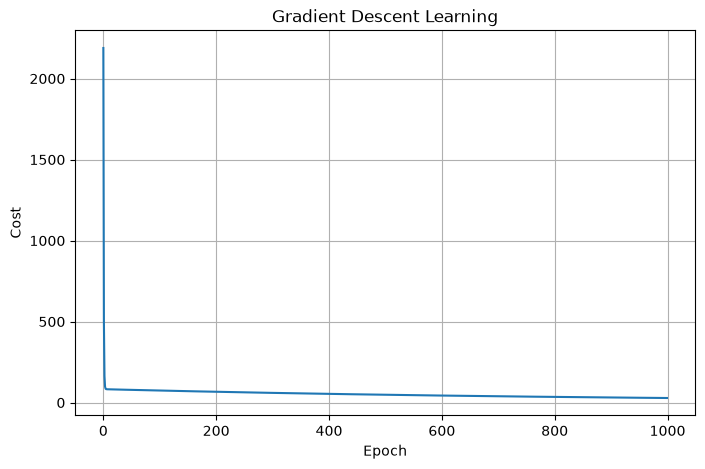

In [12]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Gradient Descent Learning")
plt.grid(True)
plt.show()

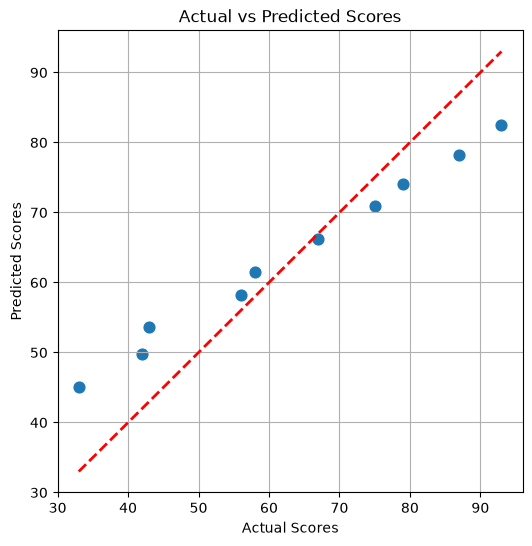

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(y, predictions, s=60)

# Perfect prediction line
plt.plot([min(y), max(y)],
         [min(y), max(y)],
         'r--',
         linewidth=2)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.grid(True)

plt.show()

USING LINEAR REGRESSION NOW

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
model = LinearRegression()

model.fit(X, y)

sk_predictions = model.predict(X)

In [16]:
print("My Model Predictions")
print(np.round(predictions, 2))

print("\nSklearn Predictions")
print(np.round(sk_predictions, 2))

My Model Predictions
[45.11 49.85 53.71 58.24 61.44 66.19 70.93 74.13 78.22 82.52]

Sklearn Predictions
[32.94 41.43 43.38 55.87 58.55 67.04 75.53 78.21 87.43 92.65]


In [17]:
print("My Model MSE :", mean_squared_error(y, predictions))
print("Sklearn MSE  :", mean_squared_error(y, sk_predictions))

print()

print("My Model R² :", r2_score(y, predictions))
print("Sklearn R²  :", r2_score(y, sk_predictions))

My Model MSE : 56.786521626855745
Sklearn MSE  : 0.20061983471074424

My Model R² : 0.8467755278409763
Sklearn R²  : 0.9994586766824675


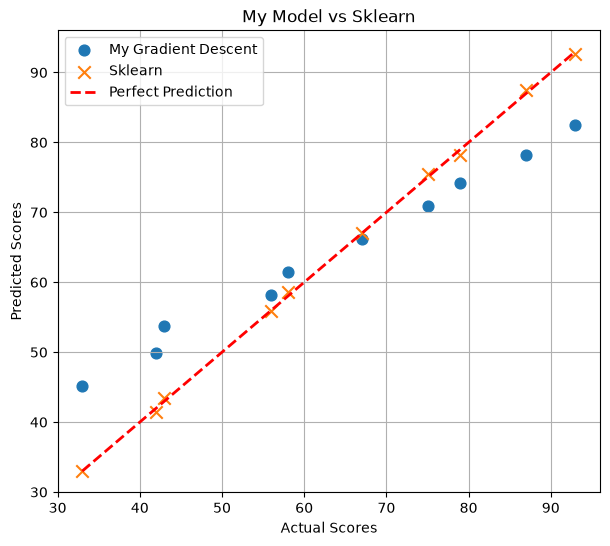

In [18]:
plt.figure(figsize=(7,6))

plt.scatter(y, predictions, label="My Gradient Descent", s=60)
plt.scatter(y, sk_predictions, label="Sklearn", marker='x', s=80)

plt.plot([min(y), max(y)],
         [min(y), max(y)],
         'r--',
         linewidth=2,
         label="Perfect Prediction")

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("My Model vs Sklearn")
plt.legend()
plt.grid(True)

plt.show()